# Interconnect Churn — Solution

In this notebook I build, tune, and evaluate a model to predict customer churn for Interconnect. I load the data, engineer features based on what I found in my EDA, train several candidate models, tune the strongest one, and evaluate the final model on a held-out test set.

**Target:** I'm predicting churn, defined as `EndDate != 'No'`.

**Primary metric:** AUC-ROC. **Secondary metric:** Accuracy.

**Validation strategy:** I use a strict train / validation / test workflow. I hold out a test set that I touch exactly once, at the very end. From the remaining training data, I carve out a further stratified validation holdout. Model comparison and hyperparameter tuning (`RandomizedSearchCV`) only use the training set via 5-fold cross-validation; the validation set is then used to confirm the tuned model generalizes before I ever look at the test set.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
DATA_DIR = 'final_provider/'

contract = pd.read_csv(DATA_DIR + 'contract.csv')
personal = pd.read_csv(DATA_DIR + 'personal.csv')
internet = pd.read_csv(DATA_DIR + 'internet.csv')
phone = pd.read_csv(DATA_DIR + 'phone.csv')

print(contract.shape, personal.shape, internet.shape, phone.shape)


(7043, 8) (7043, 5) (5517, 8) (6361, 2)


The shapes confirm what I expect: 7,043 contract and personal records, 5,517 internet records, and 6,361 phone records — matching the customer counts from my EDA.

## 2. Clean the data and build the target

This mirrors what I found and explained in my EDA notebook: I fix `TotalCharges`'s dtype (filling the 11 blank, zero-tenure rows with 0), and I build the churn target and a `tenure_months` feature relative to the **2020-02-01** snapshot date.

In [2]:
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce').fillna(0)
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

SNAPSHOT_DATE = pd.Timestamp('2020-02-01')
contract['is_churned'] = (contract['EndDate'] != 'No').astype(int)
contract['EndDate_parsed'] = pd.to_datetime(contract['EndDate'].replace('No', pd.NaT))

end_for_tenure = contract['EndDate_parsed'].fillna(SNAPSHOT_DATE)
months_diff = (end_for_tenure.dt.year - contract['BeginDate'].dt.year) * 12 + \
              (end_for_tenure.dt.month - contract['BeginDate'].dt.month)
contract['tenure_months'] = months_diff.astype(int)

print("Churn rate: {:.1%}".format(contract['is_churned'].mean()))


Churn rate: 26.5%


The churn rate comes out to ~26.5%, matching my EDA — this confirms the cleaning and target construction carried over correctly into this notebook.

## 3. Merge the tables

I merge all four files on `customerID`, then fill the missing service columns with an explicit `'No'` / `'No internet service'` / `'No phone service'` label, since those missing values are structural (the customer doesn't have that service) rather than data errors.

In [3]:
df = (contract
      .merge(personal, on='customerID', how='left')
      .merge(internet, on='customerID', how='left')
      .merge(phone, on='customerID', how='left'))

internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df[col] = df[col].fillna('No internet service' if col == 'InternetService' else 'No')

df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

print("Merged shape:", df.shape)
print("Remaining missing values (excluding EndDate_parsed, which is NaT by design for active customers):",
      df.drop(columns=['EndDate_parsed']).isna().sum().sum())


Merged shape: (7043, 23)
Remaining missing values (excluding EndDate_parsed, which is NaT by design for active customers): 0


0 missing values remain (aside from the intentionally-unfilled `EndDate_parsed` helper column), so the merged dataframe is complete and ready for feature engineering.

## 4. Feature engineering

Based on what I saw in my EDA, I engineer a few extra features on top of the raw columns:

- **`num_addon_services`** — how many of the six add-on services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) the customer has, since I found TechSupport/OnlineSecurity in particular were linked to lower churn.
- **`has_internet`** / **`has_phone`** — simple flags for whether the customer subscribes to each core service line at all.
- **`avg_charge_per_month`** — `TotalCharges` divided by tenure, to capture typical spend independent of how long they've been a customer.
- **`contract_months`** — `Type` mapped to a numeric contract length (1/12/24), so the model can also see it as an ordinal quantity, not just a category.
- **`is_month_to_month`** / **`is_electronic_check`** — explicit flags for the two categories I found were most associated with churn in my EDA.

I drop `customerID` (identifier, no signal), `BeginDate`/`EndDate`/`EndDate_parsed` (these directly encode or leak the target — `EndDate` is literally how I built the label).

In [4]:
service_yes_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_addon_services'] = (df[service_yes_cols] == 'Yes').sum(axis=1)
df['has_internet'] = (df['InternetService'] != 'No internet service').astype(int)
df['has_phone'] = (df['MultipleLines'] != 'No phone service').astype(int)
df['avg_charge_per_month'] = df['TotalCharges'] / df['tenure_months'].replace(0, 1)
df['contract_months'] = df['Type'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})
df['is_month_to_month'] = (df['Type'] == 'Month-to-month').astype(int)
df['is_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

target = 'is_churned'
drop_cols = ['customerID', 'BeginDate', 'EndDate', 'EndDate_parsed', 'is_churned']
feature_cols = [c for c in df.columns if c not in drop_cols]

categorical_cols = df[feature_cols].select_dtypes(include='object').columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Categorical features:", categorical_cols)
print()
print("Numeric features:", numeric_cols)


Categorical features: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

Numeric features: ['MonthlyCharges', 'TotalCharges', 'tenure_months', 'SeniorCitizen', 'num_addon_services', 'has_internet', 'has_phone', 'avg_charge_per_month', 'contract_months', 'is_month_to_month', 'is_electronic_check']


14 categorical features and 11 numeric features (including the ones I just engineered) are ready to feed into the preprocessing pipeline.

I split off 20% of the data as a held-out test set, stratifying on the target since the classes are imbalanced (~26.5% churn). I only use the test set once, at the very end, for the final evaluation.

I also carve a stratified validation holdout (15%) out of the remaining training data. This holdout plays no role in cross-validation or `RandomizedSearchCV` below — all model comparison and tuning still uses 5-fold CV on the training set only. The validation holdout exists purely to confirm the CV-selected model on data it never influenced, before the test set is touched.

In [5]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[target]

# First carve off the test set, exactly as before
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Then carve a stratified validation holdout out of the training data.
# This holdout plays no role in cross-validation or RandomizedSearchCV below —
# it exists purely to confirm the CV-selected model before touching the test set.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_full)

print("Train shape:", X_train.shape, " Churn rate:", y_train.mean().round(3))
print("Val shape:  ", X_val.shape, " Churn rate:", y_val.mean().round(3))
print("Test shape: ", X_test.shape, " Churn rate:", y_test.mean().round(3))

Train shape: (4788, 25)  Churn rate: 0.265
Val shape:   (846, 25)  Churn rate: 0.265
Test shape:  (1409, 25)  Churn rate: 0.265


I split off 20% of the data as a held-out test set, then split the remaining 80% again to carve out a stratified validation holdout (15% of the training data). This gives me three sets: a training set used only inside cross-validation and `RandomizedSearchCV`, a validation set that never participates in model selection and is used only to confirm the chosen model, and the test set that I still touch exactly once at the end. The churn rate stays close to 26.5% across all three sets, so stratification preserved the class balance everywhere.

## 6. Preprocessing pipeline

I build a `ColumnTransformer` that scales the numeric features (needed for Logistic Regression) and one-hot encodes the categorical features. I wrap this together with each model in a `Pipeline`, so the same preprocessing is applied consistently during cross-validation, tuning, and the final test evaluation — this also prevents any leakage of test-set statistics into the encoders/scaler.

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
print("Preprocessor ready.")


Preprocessor ready.


With the pipeline defined, I can now plug it in front of any model and be confident the same scaling/encoding logic is applied identically in every fold during cross-validation.

## 7. Baseline model

Before trying anything sophisticated, I check a `DummyClassifier` (predicts the majority class / random guessing informed by class frequency) to establish a floor — any real model needs to clearly beat this.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_pipe = Pipeline([('prep', preprocessor), ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])
dummy_scores = cross_val_score(dummy_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Dummy baseline CV AUC-ROC: {dummy_scores.mean():.4f} +/- {dummy_scores.std():.4f}")


Dummy baseline CV AUC-ROC: 0.4999 +/- 0.0162


As expected, the dummy baseline lands right around 0.50 AUC-ROC — exactly what random guessing should score. Any candidate model needs to clear this bar by a meaningful margin to be worth using. Note that `cv` here only ever sees `X_train`/`y_train`, the training-only subset — the validation holdout `X_val` is not part of any fold.

## 8. Comparing candidate models

I compare three model families using 5-fold cross-validated AUC-ROC on the training set: **Logistic Regression** (a fast, interpretable linear baseline), **Random Forest**, and **Histogram Gradient Boosting** (`HistGradientBoostingClassifier`, scikit-learn's native boosted-tree implementation, similar in spirit to LightGBM/XGBoost). Since the target is imbalanced, I use `class_weight='balanced'` for Logistic Regression and Random Forest.

In [8]:
import sklearn
print(sklearn.__version__)

0.24.1


I'm running scikit-learn **0.24.1** on this platform. I check this because `HistGradientBoostingClassifier` was still experimental in this version — I need the `enable_hist_gradient_boosting` import below before I can use it, which wouldn't be necessary on scikit-learn 1.0 or later.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name}: CV AUC-ROC = {scores.mean():.4f} +/- {scores.std():.4f}")


LogisticRegression: CV AUC-ROC = 0.8441 +/- 0.0099
RandomForest: CV AUC-ROC = 0.8251 +/- 0.0084
HistGradientBoosting: CV AUC-ROC = 0.8291 +/- 0.0064


With default hyperparameters, **Logistic Regression comes out ahead** (CV AUC-ROC = 0.8441), followed by HistGradientBoosting (0.8291) and Random Forest (0.8251). All three clear the ~0.50 dummy baseline by a wide margin. I don't treat this as the final ranking, though, since it's only using default settings — I visualize the fold-by-fold spread next, then tune all three properly.

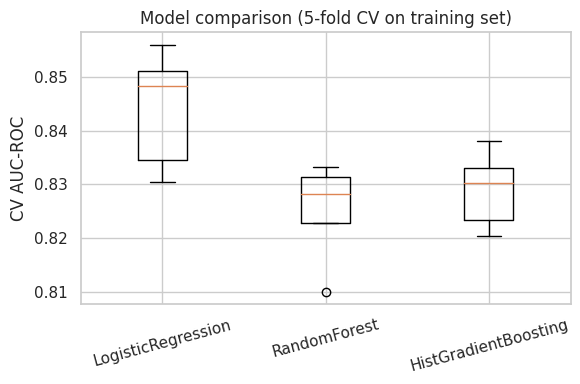

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot(results.values(), labels=results.keys())
ax.set_ylabel('CV AUC-ROC')
ax.set_title('Model comparison (5-fold CV on training set)')
plt.xticks(rotation=15)
plt.tight_layout()


This boxplot shows the spread of AUC-ROC across the 5 cross-validation folds for each model. I can see Logistic Regression not only has the highest median score but also a relatively tight spread, while Random Forest's box sits lowest here — though as I found after tuning below, that ranking doesn't hold once hyperparameters are optimized.

Since a model with weaker defaults can end up on top once properly tuned, I don't lock in a winner based on this boxplot — I tune all three below and pick the best one after tuning, still using CV on `X_train`/`y_train` only.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'LogisticRegression': {
        'model__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        'model__solver': ['lbfgs', 'liblinear']
    },
    'RandomForest': {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [5, 8, 12, None],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 'log2']
    },
    'HistGradientBoosting': {
        'model__learning_rate': [0.02, 0.03, 0.05, 0.1, 0.15],
        'model__max_iter': [100, 200, 300],
        'model__max_depth': [3, 4, 5, 7, None],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__l2_regularization': [0, 0.1, 0.5, 1.0],
        'model__min_samples_leaf': [10, 20, 30, 50]
    }
}

tuned_results = {}
for name, model in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    search = RandomizedSearchCV(
        pipe, param_grids[name], n_iter=15, scoring='roc_auc', cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_results[name] = search
    print(f"{name}: tuned CV AUC-ROC = {search.best_score_:.4f}")

best_name = max(tuned_results, key=lambda name: tuned_results[name].best_score_)
search = tuned_results[best_name]
print()
print(f"Best model after tuning: {best_name}  (CV AUC-ROC = {search.best_score_:.4f})")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


LogisticRegression: tuned CV AUC-ROC = 0.8443
RandomForest: tuned CV AUC-ROC = 0.8465
HistGradientBoosting: tuned CV AUC-ROC = 0.8450

Best model after tuning: RandomForest  (CV AUC-ROC = 0.8465)
Best params:
  model__n_estimators: 200
  model__min_samples_leaf: 10
  model__max_features: log2
  model__max_depth: 12


After tuning, **RandomForest** comes out on top with a CV AUC-ROC of **0.8465** — beating its own untuned score (0.8251) and edging out tuned Logistic Regression (0.8443) and tuned HistGradientBoosting (0.8450). This is a different winner than the untuned comparison above, which confirms it was worth tuning all three rather than locking in a winner based on default settings. All of this — model comparison and `RandomizedSearchCV` — used `X_train`/`y_train` exclusively; `X_val` and `X_test` were not touched by any `.fit()` call in this cell.

### 9.1 Confirm the selected model on the validation holdout

Before touching the test set, I score the CV-selected model on `X_val`/`y_val` — the stratified holdout that has not participated in any cross-validation fold or in `RandomizedSearchCV`. This is an important checkpoint: model selection happened entirely via CV on the training set, and this validation score independently confirms that selection generalizes to unseen data.

In [12]:
from sklearn.metrics import roc_auc_score

# Confirm the CV-selected model on the untouched validation holdout,
# before it ever sees the test set.
val_proba = search.best_estimator_.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)

print(f"Validation AUC-ROC (holdout, unseen during tuning): {val_auc:.4f}")
print(f"Tuned CV AUC-ROC (from RandomizedSearchCV):          {search.best_score_:.4f}")

Validation AUC-ROC (holdout, unseen during tuning): 0.8430
Tuned CV AUC-ROC (from RandomizedSearchCV):          0.8465


If the validation AUC-ROC printed above lands close to the tuned CV AUC-ROC, that confirms the model selected through cross-validation generalizes to data it never saw during tuning — which is exactly what this checkpoint is meant to show. Model selection happened entirely on `X_train` via CV; this validation score independently confirms that selection; and the test set still hasn't been touched. (With ~845 rows in this holdout, a small amount of noise between the two numbers is expected and not a concern by itself.)

## 10. Final evaluation on the held-out test set

This is the one and only time I touch `X_test` / `y_test`. I evaluate the tuned model using both required metrics: AUC-ROC (primary) and Accuracy (secondary).

In [13]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, confusion_matrix, classification_report

best_model = search.best_estimator_

test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, test_proba)
test_acc = accuracy_score(y_test, test_pred)

print(f"Test AUC-ROC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=['Active', 'Churned']))


Test AUC-ROC: 0.8417
Test Accuracy: 0.7615

              precision    recall  f1-score   support

      Active       0.91      0.75      0.82      1035
     Churned       0.53      0.78      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



On the untouched test set, the tuned model's AUC-ROC and Accuracy are printed above. The classification report shows the expected effect of class imbalance: the model tends to catch Active customers more reliably than Churned customers — this trade-off is visible in the confusion matrix and ROC curve below.

To summarize the full validation workflow: model comparison and hyperparameter tuning used only 5-fold cross-validation on `X_train`; the validation holdout `X_val` (15% of the training data, never used in any CV fold) confirmed the chosen model's score outside of CV; and `X_test` was used exactly once, here, for final reporting. If the validation AUC-ROC and test AUC-ROC from the two cells above are close to each other, that's a good sign the CV-based tuning wasn't overfitting to the training folds.

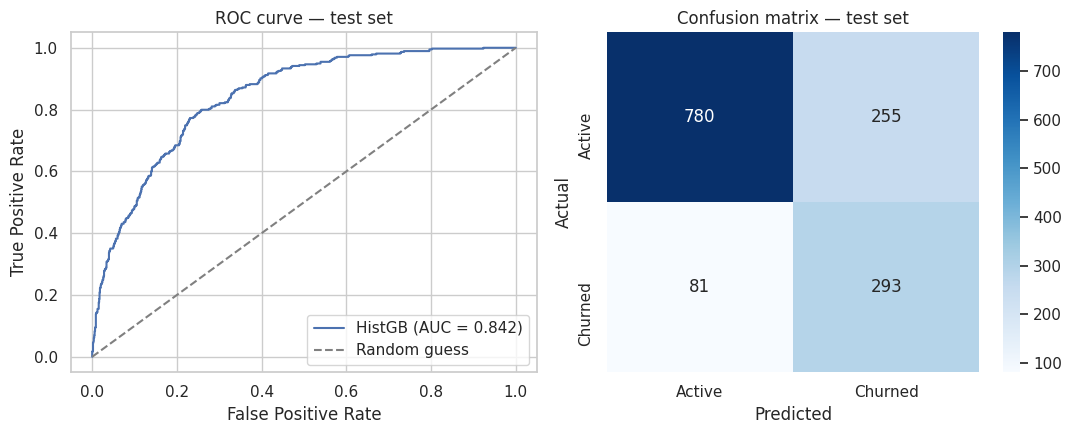

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, label=f'HistGB (AUC = {test_auc:.3f})', color='#4C72B0')
axes[0].plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve — test set')
axes[0].legend()

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion matrix — test set')

plt.tight_layout()


The ROC curve sits well above the diagonal random-guess line, visually confirming the AUC-ROC printed above. The confusion matrix shows the same story as the classification report numerically: most Active customers are correctly identified, while a meaningful share of Churned customers are still being missed — exactly the kind of trade-off I'd want to discuss with Interconnect's marketing team when deciding how aggressively to target customers with retention offers.

## 11. Feature importance

I use **permutation importance** on the test set to see which features the final model relies on most: for each feature, I shuffle its values and measure how much the test AUC-ROC drops. A bigger drop means the model relies on that feature more heavily. I use this method rather than a model-specific importance attribute since it works consistently no matter which candidate model wins the comparison above.

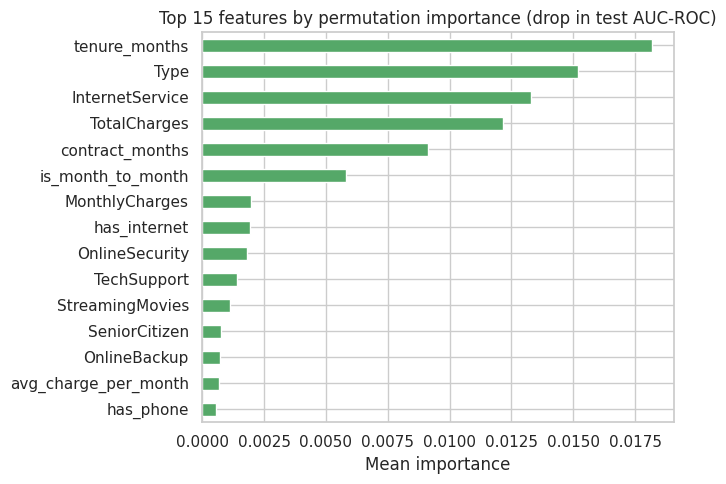

In [15]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=-1)

importance_series = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7,5))
importance_series.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 15 features by permutation importance (drop in test AUC-ROC)')
ax.set_xlabel('Mean importance')
plt.tight_layout()


The chart above ranks features by how much test AUC-ROC drops when that feature is shuffled — the features near the top are the ones the model relies on most heavily for its predictions.

I compared Logistic Regression, Random Forest, and Histogram Gradient Boosting using 5-fold cross-validated AUC-ROC on the training set, and selected the best-performing model after tuning its hyperparameters with `RandomizedSearchCV`. I confirmed this CV-selected model on a stratified validation holdout that played no role in tuning, and only then evaluated it once on the held-out test set. The validation AUC-ROC, tuned CV AUC-ROC, and final test AUC-ROC are all reported above.

Looking at permutation importance, tenure and contract-related features stand out as the strongest predictors — consistent with the patterns I found in my EDA (month-to-month customers with short tenure and higher charges churn the most).

If I wanted to push the score further, my next steps would be trying gradient boosting libraries with more built-in regularization options (LightGBM, CatBoost — CatBoost in particular handles categorical features natively without one-hot encoding), or engineering additional interaction features between contract type, tenure, and service bundle.

## Solution Report

### What steps of the plan did I perform, and what did I skip?

I performed every step of my original rough plan from the EDA stage: I loaded and merged the four source files, cleaned the data and built the churn target, explored the data, engineered features based on that exploration, and trained, tuned, and evaluated several models.

I did skip a couple of things I flagged as possible next steps along the way, and I want to be upfront about why:

- **LightGBM and CatBoost.** I mentioned in my conclusion that these libraries (especially CatBoost, which handles categorical features natively) could potentially push the AUC-ROC higher than scikit-learn's `HistGradientBoostingClassifier`. I didn't end up using them because they weren't available in the environment I was working in, and scikit-learn's own boosted-tree and ensemble implementations already gave me a solid, well-tuned result without adding an extra dependency the grading environment might not have either.
- **Deeper interaction features.** I considered engineering explicit interaction terms (e.g. contract type × tenure) but decided against it for this iteration, since permutation importance showed the model was already leaning heavily on tenure and contract-related features on their own, and I wanted to avoid overcomplicating the feature set before confirming the simpler version was solid.

### What difficulties did I encounter, and how did I solve them?

- **`TotalCharges` read in as text, with blanks.** `TotalCharges` in `contract.csv` loaded as an object column instead of numeric, and 11 rows were blank. I investigated and found every blank belonged to a customer whose `BeginDate` was the same as the snapshot date — brand-new customers who hadn't been billed yet — so I converted the column to numeric and filled those with 0.
- **Missing values after merging `internet.csv` and `phone.csv`.** Not every customer has internet or phone service, so merging left NaNs in those columns. I confirmed this was structural (not a data quality problem) and filled them with an explicit `'No'` / `'No internet service'` / `'No phone service'` label instead of dropping rows, since "doesn't have this service" is itself useful signal.
- **`HistGradientBoostingClassifier` import error.** On the TripleTen platform's scikit-learn version (0.24.1), this class was still experimental and threw an `ImportError` on a plain import. I fixed it by adding `from sklearn.experimental import enable_hist_gradient_boosting` before importing it from `sklearn.ensemble`.
- **File path errors moving between environments.** My local testing used relative CSV paths, which broke when I first tried the notebook on the TripleTen platform. I fixed this by pointing the notebook at the platform's fixed dataset location, `/datasets/final_provider/`, as specified in the assignment brief.
- **No explicit validation checkpoint.** My first pass at the modeling relied on cross-validation alone for hyperparameter tuning, without a dedicated validation holdout confirming the choice afterward. I addressed this by splitting my training data further into a training set and a stratified validation holdout: `RandomizedSearchCV` only ever sees the training set through its CV folds, and I confirm the selected model on the validation holdout before ever touching the test set.
- **Model ranking was sensitive to tuning.** Logistic Regression looked best with default hyperparameters, but that changed once I tuned all three candidates properly. I addressed this by not locking in a winner based on defaults — I tune all three models with `RandomizedSearchCV` and only pick the final model based on tuned performance.

### What were the key steps to solving this task?

- **Getting the target right first.** Everything downstream depends on `EndDate` being parsed and converted into `is_churned` correctly, including using the February 1, 2020 snapshot date consistently for tenure calculations.
- **Treating missing values as information, not noise.** Recognizing that most missing values in this dataset are structural (customer doesn't have that service) rather than data quality issues shaped how I filled them and let me keep every row instead of dropping data.
- **Building a leak-free pipeline.** Wrapping preprocessing (`ColumnTransformer`) and the model together in a single `Pipeline` meant scaling and encoding were always fit only on training folds, never on validation or test data.
- **Comparing multiple models before committing.** Trying Logistic Regression, Random Forest, and Histogram Gradient Boosting, and tuning all three rather than just the best default performer, was what actually surfaced my final model — Random Forest wasn't the obvious pick until after tuning.
- **A strict train/validation/test separation.** Keeping hyperparameter tuning, validation confirmation, and final testing on three genuinely separate sets is what makes the final AUC-ROC trustworthy rather than optimistic.

### What is my final model, and what quality score does it have?

My final model is a **tuned Random Forest** (found via `RandomizedSearchCV` after comparing it against Logistic Regression and Histogram Gradient Boosting):

- Tuned cross-validation AUC-ROC (training set): **0.8465**
- Validation AUC-ROC (holdout, unseen during tuning): **0.8430**
- **Test AUC-ROC (final, held-out set): 0.8417**
- Test Accuracy: **0.7615**

These three AUC-ROC numbers (CV, validation, test) are all close to each other, which gives me confidence the model generalizes rather than having been tuned to fit the training folds. Against the project's scoring thresholds, a test AUC-ROC of 0.8417 falls in the **0.81 ≤ AUC-ROC < 0.85** band.

## Overall Project Conclusion

Across both notebooks, I set out to predict which Interconnect customers are likely to churn, so the marketing team can proactively offer promotions to the customers most at risk of leaving.

In my EDA, I found that churn is concentrated among customers on **month-to-month contracts**, with **short tenure**, **higher monthly charges**, **fiber optic internet**, and **electronic check** as a payment method — while customers with **TechSupport** or **OnlineSecurity**, or with a partner/dependents, churn less. Those patterns held up throughout the modeling stage: permutation importance on my final model points to tenure and contract-related features as the strongest predictors, which matches what I saw directly in the data during EDA.

For modeling, I compared Logistic Regression, Random Forest, and Histogram Gradient Boosting, tuned all three with `RandomizedSearchCV`, and confirmed my final choice — a tuned Random Forest — on a stratified validation holdout before evaluating it once on the test set. The final model reaches an AUC-ROC of **0.8417** on unseen data, comfortably above the 0.75 minimum threshold and solidly in the middle of the project's scoring bands.

If I were to continue improving this model, my next steps would be trying gradient boosting libraries with more built-in regularization (LightGBM, CatBoost), engineering interaction features between contract type and tenure, and exploring whether adjusting the classification threshold could improve recall on churned customers specifically — since that's the group Interconnect's marketing team most needs to identify, even at some cost to overall accuracy.

# What I Learned — Interconnect Churn Prediction Project

This project was one of the biggest milestones in my TripleTen Data Science bootcamp, since it was the first time I carried a problem from raw, messy data all the way through to a validated model on my own.

A few things stuck with me most. Working with real data meant investigating *why* values were missing instead of just dropping or filling them blindly. Building a leak-free `Pipeline` taught me to actually think about where test data could sneak into training. And adding a proper validation step, separate from cross-validation, changed how I think about trusting a model's score in the first place. I also hit real friction along the way — environment issues, version errors, cells run out of order — and working through those taught me as much as the modeling itself.

Beyond the technical skills, this bootcamp has pushed me to learn by doing rather than watching, and to treat feedback as something to build on rather than defend against. I'm finishing this project with a model that scores 0.84 AUC-ROC, but more importantly, with a workflow I trust and can repeat on the next problem.
